# 05. Train / Validation / Test Split

This topic is extremely important because it tells us:

> "How do we know if our model will work on unseen data?"

---

# The Problem

Suppose you have 1000 examples.

If you train and evaluate on the same data:

```python
model.fit(X, y)

model.predict(X)
```

you may get:

```text
98% accuracy
```

Looks amazing.

But this number is misleading.

The model has already seen those examples.

---

# Intuition

Imagine a student.

### Wrong Evaluation

Teach 100 questions.

Then ask the same 100 questions in the exam.

Student scores:

```text
100/100
```

Did the student learn?

Maybe.

Or maybe they memorized.

---

### Proper Evaluation

Teach 100 questions.

Ask 20 completely new questions.

Now you measure actual learning.

ML works exactly the same way.

---

# The Three Datasets

We split data into:

```text
Training Set
Validation Set
Test Set
```

---

## 1. Training Set

Used to learn parameters.

For linear regression:

**`w,b`**

are learned from training data.

---

Example:

```text
700 samples
```

Model learns from them.

---

## 2. Validation Set

Used for model selection.

Questions like:

* Degree 2 or degree 5?
* Learning rate 0.01 or 0.001?
* Regularization λ = 1 or λ = 10?

are answered using validation performance.

---

The model never learns from validation data.

Validation only helps us choose settings.

---

## 3. Test Set

Used once at the very end.

Purpose:

> Estimate real-world performance.

This is the closest thing to unseen future data.

---

# Typical Split

Common:

```text
Train      70%
Validation 15%
Test       15%
```

or

```text
Train      80%
Validation 10%
Test       10%
```

---

For 1000 examples:

```text
700 Train
150 Validation
150 Test
```

---

# Workflow

Step 1:

Train model on training set.

```python
model.fit(X_train, y_train)
```

---

Step 2:

Evaluate on validation set.

```python
val_score = model.score(X_val, y_val)
```

---

Step 3:

Choose best hyperparameters.

---

Step 4:

Evaluate once on test set.

```python
test_score = model.score(X_test, y_test)
```

---

Step 5:

Report test performance.

Done.

---

# Why Not Use Test Set Repeatedly?

Suppose:

```text
Model A → 85%
Model B → 88%
Model C → 90%
```

You keep selecting based on test performance.

Eventually you're indirectly tuning for the test set.

Now the test set is no longer truly unseen.

It becomes another validation set.

---

Therefore:

```text
Validation -> tuning
Test -> final evaluation
```

---

# Mathematical View

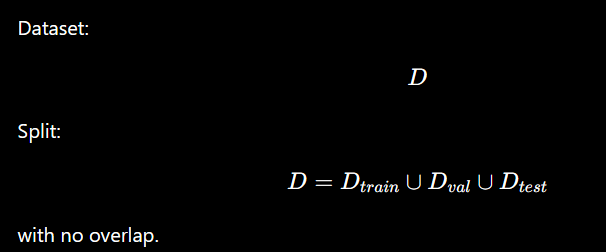

---

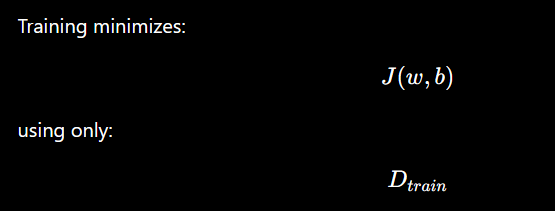

---

Validation and test are never used in gradient descent.

---

# Relation with Scaling

Remember Z-score normalization?

Correct way:

```python
scaler.fit(X_train)
```

Learn:

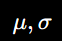

from training data only.

---

Then:

```python
scaler.transform(X_train)

scaler.transform(X_val)

scaler.transform(X_test)
```

---

Wrong:

```python
scaler.fit(X_test)
```

because you're leaking future information.

This is called **data leakage**.

---

# Data Leakage

One of the biggest ML mistakes.

Example:

```python
scaler.fit(X)
```

before splitting.

Now information from validation and test has already influenced preprocessing.

Your evaluation becomes overly optimistic.

---

Correct order:

```text
Split Data
↓
Fit scaler on train
↓
Transform train
↓
Transform validation
↓
Transform test
```

---

# Python Example

```python
from sklearn.model_selection import train_test_split
```

Split train and temporary:

```python
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)
```

---

Split temp again:

```python
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)
```

Now:

```text
70% Train
15% Validation
15% Test
```

---

# Common Beginner Mistake

Thinking:

```text
Validation and Test are the same thing
```

They are not.

Validation:

```text
Choose model
```

Test:

```text
Judge final model
```

---

# What You Should Remember

1. Training set learns the parameters.
2. Validation set chooses hyperparameters and model complexity.
3. Test set estimates final real-world performance.
4. Never train on validation or test data.
5. Never fit scalers on validation or test data.
6. Data leakage can make results look better than they really are.
7. Validation is for tuning; test is for final evaluation.

The next topics (**Overfitting** and **Underfitting**) are much easier once you understand Train/Validation/Test.


Train Set
---------
Purpose:
- Learn model parameters (w, b)
- Learn preprocessing parameters (mean, std, encodings, etc.)

Scaler:
- fit(X_train)
- transform(X_train)

Validation Set
--------------
Purpose:
- Tune hyperparameters
- Compare models
- Feature selection

Scaler:
- transform(X_val)
- Never fit on validation data

Test Set
--------
Purpose:
- Final unbiased evaluation
- Used only after all decisions are made

Scaler:
- transform(X_test)
- Never fit on test data

Key Rule
--------
fit()      -> only on training set
transform() -> on train, validation, and test using training statistics

Why?
----
If validation/test are used in fit(), information leaks into training,
making performance estimates overly optimistic (data leakage).